In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub

/kaggle/input/datasets/ibrahimelsayed182/superstore/SampleSuperstore.csv


In [2]:
# Import libraries for visualisation 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Safe data loading
file_path = "/kaggle/input/datasets/ibrahimelsayed182/superstore/SampleSuperstore.csv"

try:
    df = pd.read_csv(file_path)
    print('Loaded successfully')
except FileNotFoundError:
    print(f'File Not Found - Check: {file_path}')
except Exception as e:
    print(f'Unexpected Error occured - Check: {file_path}')

Loaded successfully


# Data Inspection

In [4]:
# Check Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [5]:
# Check for Dataset Metrics
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
# Check Dataset Shape
print(f'Rows:{df.shape[0]} -- Columns:{df.shape[1]}')

Rows:9994 -- Columns:13


In [7]:
# Check Dataset Head
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [8]:
# Check for Missing Values
df.isna().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(17)

In [10]:
# Checking on the duplicates
duplicates = df[df.duplicated(keep=False)]
duplicates

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
568,Standard Class,Corporate,United States,Seattle,Washington,98105,West,Office Supplies,Paper,19.440,3,0.0,9.3312
591,Standard Class,Consumer,United States,Salem,Oregon,97301,West,Office Supplies,Paper,10.368,2,0.2,3.6288
935,Standard Class,Home Office,United States,Philadelphia,Pennsylvania,19120,East,Office Supplies,Paper,15.552,3,0.2,5.4432
950,Standard Class,Home Office,United States,Philadelphia,Pennsylvania,19120,East,Office Supplies,Paper,15.552,3,0.2,5.4432
1186,Standard Class,Corporate,United States,Seattle,Washington,98103,West,Office Supplies,Paper,25.920,4,0.0,12.4416
1479,Standard Class,Consumer,United States,San Francisco,California,94122,West,Office Supplies,Paper,25.920,4,0.0,12.4416
2803,Standard Class,Consumer,United States,San Francisco,California,94122,West,Office Supplies,Paper,12.840,3,0.0,5.7780
2807,Second Class,Consumer,United States,Seattle,Washington,98115,West,Office Supplies,Paper,12.960,2,0.0,6.2208
2836,Standard Class,Consumer,United States,Los Angeles,California,90036,West,Office Supplies,Paper,19.440,3,0.0,9.3312
3127,Standard Class,Consumer,United States,New York City,New York,10011,East,Office Supplies,Paper,49.120,4,0.0,23.0864


In [11]:
# Remove fully duplicated rows

df = df.drop_duplicates()

print(f"Dataset shape after removing duplicates: {df.shape}")

Dataset shape after removing duplicates: (9977, 13)


In [12]:
# Check for Remaining duplicates
print(f"Remaining duplicates: {df.duplicated().sum()}")

Remaining duplicates: 0


**Note:** The dataset contains no missing values.

A duplicate check identified fully identical rows within the dataset. These duplicate observations were removed to prevent repeated records from influencing further analysis.

The descriptive statistics reveal unusually low profit values, with a minimum profit of -$6,599.98. These negative values will be investigated further to determine whether they are caused by discounts, specific products, or other business factors.

# Exploratory Data Analysis

In [13]:
# Convert 'Postal Code' into string
df['Postal Code'] = df['Postal Code'].astype(str).str.zfill(5)

# Check for dtype of 'Postal Code'
print(df['Postal Code'].dtype)

object


In [14]:
df['Postal Code'].head()

0    42420
1    42420
2    90036
3    33311
4    33311
Name: Postal Code, dtype: object

In [15]:
# First analysis of most common category
print(df.groupby('Category')['Sales'].agg(['count', 'sum', 'mean']).sort_values(by='sum', ascending=False).round(2))

                 count        sum    mean
Category                                 
Technology        1847  836154.03  452.71
Furniture         2118  741306.31  350.00
Office Supplies   6012  718735.24  119.55


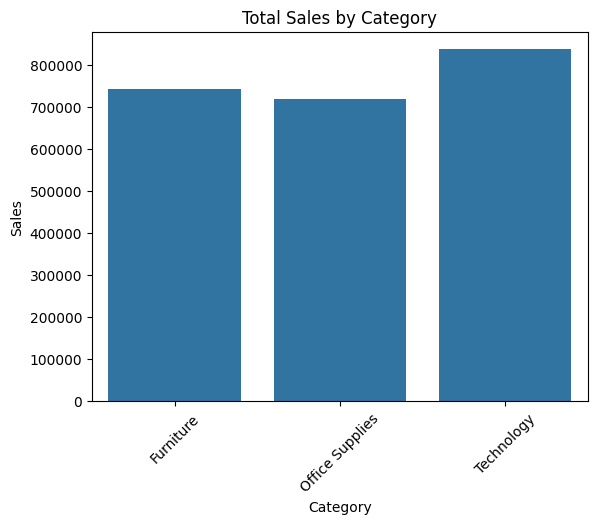

In [16]:
sns.barplot(
    data=df,
    x="Category",
    y="Sales",
    estimator=sum, 
    errorbar=None
)
plt.title("Total Sales by Category")
plt.xticks(rotation=45)
plt.show()

**Analysis:**  
The analysis shows that **Office Supplies** has the highest number of transactions, while **Technology** generates the highest total revenue despite having fewer transactions. This indicates that Technology products have a significantly higher average sales value per order.

**Recommendation:**  
Since Office Supplies accounts for the highest transaction volume, it may offer opportunities for revenue growth. However, further analysis of pricing, customer demand, and price elasticity should be conducted before considering any price adjustments.

In [17]:
# Check for the most common sub category
print(df.groupby('Sub-Category')['Sales'].agg(['count', 'sum', 'mean']).sort_values(by='sum', ascending=False).round(2))

              count        sum     mean
Sub-Category                           
Phones          889  330007.05   371.21
Chairs          615  327777.76   532.97
Storage         846  223843.61   264.59
Tables          319  206965.53   648.79
Binders        1522  203409.17   133.65
Machines        115  189238.63  1645.55
Accessories     775  167380.32   215.97
Copiers          68  149528.03  2198.94
Bookcases       228  114880.00   503.86
Appliances      466  107532.16   230.76
Furnishings     956   91683.02    95.90
Paper          1359   78224.14    57.56
Supplies        190   46673.54   245.65
Art             795   27107.03    34.10
Envelopes       254   16476.40    64.87
Labels          363   12444.91    34.28
Fasteners       217    3024.28    13.94


**Analysis:**  
The analysis shows that the top three sub-categories by total revenue are:

- Phones
- Chairs
- Storage

Although these sub-categories do not have the highest transaction volume, they generate the most revenue. This suggests that their strong revenue performance is driven by a combination of transaction volume and average sales value rather than by either factor alone.

**Recommendation:**  
These high-performing sub-categories should be analyzed further to identify opportunities for sustainable revenue growth, such as product mix optimization or pricing strategies. For the lowest-performing sub-categories, additional analysis should evaluate whether promotional campaigns, product bundles, or assortment adjustments could increase both transaction volume and revenue.

In [18]:
# Question: Which Segment does the most number of transactions
print(df.groupby(['Segment', 'Category'])['Sales'].agg(['count', 'sum', 'mean']).sort_values(by='sum', ascending=False).round(2))

                             count        sum    mean
Segment     Category                                 
Consumer    Technology         951  406399.90  427.34
            Furniture         1112  390659.34  351.31
            Office Supplies   3120  363773.54  116.59
Corporate   Technology         554  246450.12  444.86
            Office Supplies   1815  230600.23  127.05
            Furniture          646  229019.79  354.52
Home Office Technology         342  183304.02  535.98
            Office Supplies   1077  124361.48  115.47
            Furniture          360  121627.19  337.85


**Analysis:**  
The analysis shows that the **Consumer** segment generates the highest number of transactions and the highest total revenue across all three product categories. **Corporate** is the second-largest segment, followed by **Home Office**.

Technology generates the highest revenue in every customer segment despite having fewer transactions than Office Supplies. This indicates a higher average sales value per transaction for Technology products. In contrast, Office Supplies has the highest transaction volume but the lowest average sales value.

**Recommendation:**  
The Consumer segment should remain a key target for revenue growth due to its high transaction volume and revenue contribution. For Office Supplies, additional analysis should evaluate whether pricing strategies, product bundling, or cross-selling opportunities could increase the average order value while maintaining the current sales volume.

In [19]:
# Question: Which Category has the highest profit
print(df.groupby('Category')['Profit'].agg(['count', 'sum', 'mean']).sort_values(by='sum', ascending=False).round(2))

                 count        sum   mean
Category                                
Technology        1847  145454.95  78.75
Office Supplies   6012  122364.66  20.35
Furniture         2118   18421.81   8.70


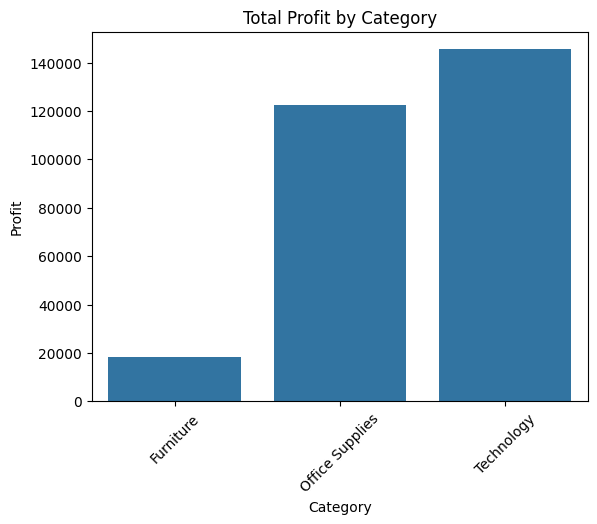

In [20]:
sns.barplot(
    data=df,
    x="Category",
    y="Profit",
    estimator=sum, 
    errorbar=None
)
plt.title("Total Profit by Category")
plt.xticks(rotation=45)
plt.show()

**Analysis:**<br>
The analysis reveals that the **Technology** category generates the majority of the total profit, despite recording the lowest transaction volume. **Office Supplies** ranks second in overall profit while accounting for the highest number of transactions.<br>

**Recommendations:**<br>
Although Furniture ranks second in transaction volume, it yields a disproportionately low overall profit and a weak average profit per transaction. It is highly recommended to investigate current discount structures and evaluate alternative pricing strategies, such as product bundling or targeted marketing offers, to improve profit margins in this category.

In [21]:
# Question: Which Sub-Category has the highest profit
print(df.groupby('Sub-Category')['Profit'].agg(['count', 'sum', 'mean']).sort_values(by='sum', ascending=False).round(2))

              count       sum    mean
Sub-Category                         
Copiers          68  55617.82  817.91
Phones          889  44515.73   50.07
Accessories     775  41936.64   54.11
Paper          1359  33944.24   24.98
Binders        1522  30228.00   19.86
Chairs          615  26567.13   43.20
Storage         846  21278.83   25.15
Appliances      466  18138.01   38.92
Furnishings     956  13052.72   13.65
Envelopes       254   6964.18   27.42
Art             795   6524.61    8.21
Labels          363   5526.38   15.22
Machines        115   3384.76   29.43
Fasteners       217    949.52    4.38
Supplies        190  -1189.10   -6.26
Bookcases       228  -3472.56  -15.23
Tables          319 -17725.48  -55.57


**Analysis:**  
The analysis shows that **Copiers** is the most profitable sub-category, generating the highest total profit despite having only 68 transactions. This is driven by its exceptionally high average profit per order.

**Phones** and **Accessories** are also among the top-performing sub-categories. Unlike Copiers, their strong profitability is mainly supported by a high number of transactions combined with consistent average profits.

At the other end, **Tables**, **Bookcases**, and **Supplies** generate negative total profits, indicating that these sub-categories may be affected by high discounts, pricing issues, or operational costs that reduce profitability.

**Recommendation:**  
The company should continue to strengthen high-performing sub-categories such as Copiers, Phones, and Accessories. For loss-making sub-categories, further analysis should identify the underlying causes of negative profitability, including discount strategies, pricing, and product costs, before implementing corrective actions.

In [22]:
# Check for the high negative profit
display(df[df['Profit']< 0].sort_values(by='Profit'))

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
7772,Standard Class,Consumer,United States,Lancaster,Ohio,43130,East,Technology,Machines,4499.985,5,0.7,-6599.9780
683,Same Day,Corporate,United States,Burlington,North Carolina,27217,South,Technology,Machines,7999.980,4,0.5,-3839.9904
9774,Standard Class,Consumer,United States,San Antonio,Texas,78207,Central,Office Supplies,Binders,2177.584,8,0.8,-3701.8928
3011,Standard Class,Home Office,United States,Louisville,Colorado,80027,West,Technology,Machines,2549.985,5,0.7,-3399.9800
4991,Standard Class,Corporate,United States,Chicago,Illinois,60653,Central,Office Supplies,Binders,1889.990,5,0.8,-2929.4845
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4660,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Technology,Accessories,27.552,3,0.2,-0.3444
7413,Standard Class,Home Office,United States,Tigard,Oregon,97224,West,Furniture,Furnishings,13.592,1,0.2,-0.3398
1566,First Class,Consumer,United States,Allen,Texas,75002,Central,Technology,Accessories,21.480,3,0.2,-0.2685
1496,Standard Class,Consumer,United States,Coppell,Texas,75019,Central,Office Supplies,Storage,16.784,1,0.2,-0.2098


**Analysis:** <br>
Further investigation into the negative profit margins reveals that the most extreme losses are driven by the Machines (Technology) and Binders (Office Supplies) sub-categories.
The root cause of these massive losses is deeply tied to the pricing strategy. The data shows that extreme discounts ranging from 50% to 80% were applied to high-ticket items like 3D printers and electric binding systems. While this strategy might drive sales volume or clear out inventory, it completely destroys profitability.

**Recommendation:** <br>
The business must review its discount policies for high-value items. Capping maximum discounts on Technology products and expensive Office Supplies could immediately eliminate these drastic financial losses.

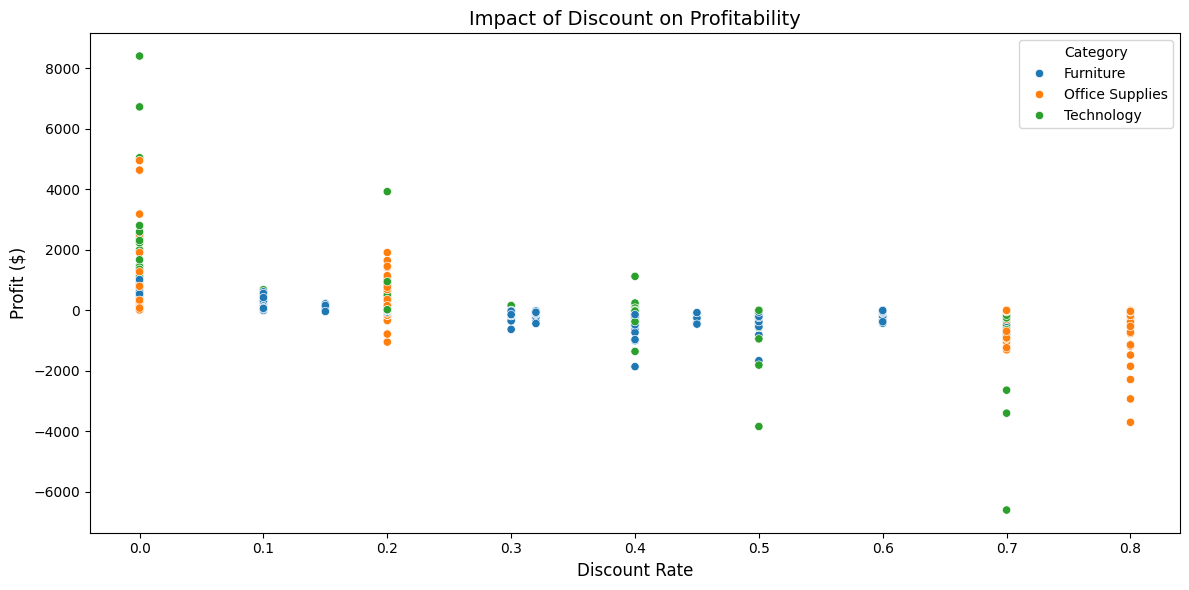

In [23]:
# Visualize the impact of Discount on Profit

plt.figure(figsize=(12,6))

sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category')
plt.title('Impact of Discount on Profitability', fontsize=14)
plt.xlabel('Discount Rate', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)

plt.tight_layout()
plt.show()


**Analysis:** <br>
The scatterplot clearly illustrates the severe negative impact of discounts on profitability. While low or zero discounts maintain positive profit margins. Discounts above 20% (0.2) are frequently associated with negative profit. Furthermore, the visual highlights that the most extreme discount levels (up to 80%) are predominantly applied to the Office Supplies category.

In [24]:
# Check for Sales and Profit by Region
print('Overview Sales by Region')
display(df.groupby('Region')['Sales'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False).round(2))
print('Overview Profit by Region')
display(df.groupby('Region')['Profit'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False).round(2))

Overview Sales by Region


,sum,mean,count
Region,,,
West,725255.64,227.14,3193
East,678435.20,238.47,2845
Central,500782.85,215.95,2319
South,391721.90,241.80,1620


Overview Profit by Region


,sum,mean,count
Region,,,
West,108329.81,33.93,3193
East,91506.31,32.16,2845
South,46749.43,28.86,1620
Central,39655.88,17.10,2319


In [25]:
# Check for the top 5 States for Sales & Profit
print('Overview Sales by State - Top 5')
display(df.groupby('State')['Sales'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False).head(5))
print('Overview Profit by State - Top 5')
display(df.groupby('State')['Profit'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False).head(5))

Overview Sales by State - Top 5


,sum,mean,count
State,,,
California,457576.2715,229.246629,1996
New York,310827.1510,275.800489,1127
Texas,170124.5418,173.066675,983
Washington,138560.8100,276.017550,502
Pennsylvania,116496.3620,198.799253,586


Overview Profit by State - Top 5


,sum,mean,count
State,,,
California,76330.7891,38.241878,1996
New York,74015.4622,65.674767,1127
Washington,33368.2375,66.470593,502
Michigan,24428.0903,96.173584,254
Virginia,18597.9504,83.026564,224


**Sales vs. Profit by State:**
By comparing the Top 5 states in terms of total Sales and total Profit, there are three distinct categories of state performance:

*   **The Consistent Leaders (High Volume & High Profit):** 
    **California, New York, and Washington** are the backbone of the business. They successfully convert high sales volumes into high total profits, making them the most reliable markets.
*   **The Hidden Champions (High Margins):** 
    **Michigan and Virginia** are not in the Top 5 for total sales, yet they rank #4 and #5 in total profit. Michigan is particularly impressive, generating an average profit of ~$95 per order. This indicates a highly profitable product mix or very efficient pricing strategies in these regions.
*   **The Profit Killers (High Revenue, Low Profit):** 
    **Texas and Pennsylvania** raise a major red flag. Despite ranking #3 and #5 in total sales (generating massive revenue and high order counts), they completely drop out of the Top 5 for profit. 

**Conclusion & Next Steps:**
Revenue does not equal profitability. The data strongly suggests that the high sales volumes in Texas and Pennsylvania are driven by aggressive price reductions that destroy the profit margin. The next logical step is to investigate the `Discount` distribution specifically in these underperforming states.

In [26]:
# Check Profit Margin by Sub-Category
subcat_margin = (df.groupby('Sub-Category').agg({'Sales' : 'sum', 'Profit' : 'sum'}))
subcat_margin['Profit_Margin'] = (subcat_margin['Profit'] / subcat_margin['Sales'])

display(subcat_margin.sort_values(by='Profit_Margin',ascending=False).round(3))

,Sales,Profit,Profit_Margin
Sub-Category,,,
Labels,12444.912,5526.382,0.444
Paper,78224.142,33944.240,0.434
Envelopes,16476.402,6964.177,0.423
Copiers,149528.030,55617.825,0.372
Fasteners,3024.280,949.518,0.314
Accessories,167380.318,41936.636,0.251
Art,27107.032,6524.612,0.241
Appliances,107532.161,18138.005,0.169
Binders,203409.169,30228.000,0.149


**Analysis:**  
The analysis shows that **Labels**, **Paper**, **Envelopes**, and **Copiers** achieve the highest profit margins, indicating that these sub-categories convert a large proportion of their sales into profit. While Copiers generate the highest total profit, Labels, Paper, and Envelopes are the most efficient in terms of profitability relative to sales.

On the other hand, **Tables**, **Bookcases**, and **Supplies** have negative profit margins, meaning that these sub-categories generate an overall loss despite producing sales revenue. This suggests that their current pricing, discount strategy, or cost structure may be negatively affecting profitability.

**Recommendation:**  
The company should continue to strengthen high-margin sub-categories while maintaining their competitive position. For sub-categories with negative profit margins, further analysis should investigate the underlying causes, such as excessive discounts, pricing policies, or product costs, before implementing corrective actions.

## Executive Summary

The objective of this exploratory data analysis (EDA) was to identify key sales and profitability trends across products, customer segments, regions, and time periods within the Superstore dataset.

The analysis reveals that Technology is the strongest performing product category, generating both the highest total sales and overall profit despite having fewer transactions than Office Supplies. This indicates that Technology products achieve a significantly higher average order value and contribute more effectively to overall profitability.

At the sub-category level, Copiers generate the highest total profit and the highest average profit per transaction. In addition, Labels, Paper, and Envelopes achieve the highest profit margins, demonstrating excellent profitability relative to their sales revenue. Conversely, Tables, Bookcases, and Supplies consistently generate losses, highlighting opportunities for further investigation into pricing strategies, discount policies, or operational costs.

Customer segmentation shows that the Consumer segment accounts for the largest share of transactions and revenue across all categories, making it the company’s most valuable customer group. While Corporate and Home Office customers contribute lower sales volumes, they still represent important revenue sources and may benefit from targeted marketing strategies.

Overall, the findings demonstrate that strong sales performance does not always translate into high profitability. Combining sales, profit, and profit margin analyses provides a more comprehensive understanding of business performance and supports more informed decision-making.